# Advanced Chemical Reaction Engieering (CBE 60546)
## Homework 3
## Due September 22, 2025

Carefully and neatly document your answers. Use Jupyter/Collab for all plots. See sample code at https://github.com/wmfschneider/CBE60546/blob/main/Resources/Examples.ipynb.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats          # one of several options for doing linear regression

# Q.1. Langmuir adsorption
##  The table below shows the mass of carbon monoxide taken up by a 10 wt% Ru on alumina sample (i.e., particles of Ru on an inert support) as a function of CO pressure at 100ºC. CO is known to only adsorb on Ru at these conditions.
|$P_{CO}$ (torr) | 100 | 150 | 200 | 250 | 300 | 400|
| --- | --- | --- | --- | --- | --- | --- |
|CO adsorbed ($\mu$mol/ g sample)| 1.28 | 1.63| 1.77 | 1.94 | 2.06 | 2.21|

### Q1.1. Plot the data and use non-linear regression to estimate the value of the uptake equilibrium constant.

In [2]:
P_CO = np.array([100,150,200,250,300,400]) * 0.00133322 # From torr to bar
CO_ads = np.array([1.28,1.63,1.77,1.94,2.06,2.21])

In [3]:
# Function to fit: theta = K_ads*P/(1+K_ads*P), theta = CO_ads / CO_ads_max
def Langmuir(P,CO_ads_max, K_ads):
  return K_ads*P/(1+K_ads*P)*CO_ads_max

In [4]:
initial_guesses = 3,1 # For CO_ads_max and K_ads
popt, pcov = curve_fit(Langmuir, P_CO, CO_ads, initial_guesses)
print ('The uptake equilibrium constant is {:.2f}.'.format(popt[1]))

The uptake equilibrium constant is 6.12.


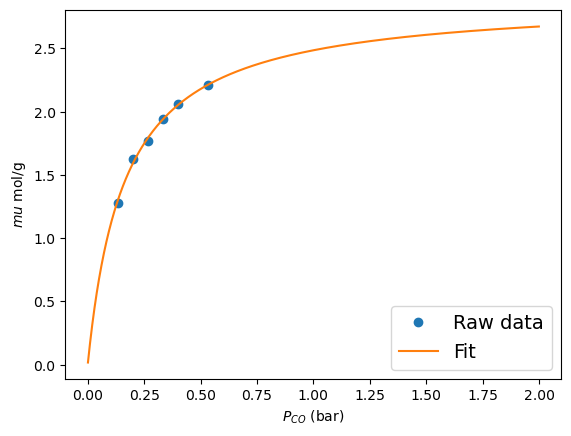

In [5]:
plt.plot(P_CO,CO_ads, 'o', label = 'Raw data')
# Extrapolate the curve to low P to check if it passes (0,0) and high P to check the max uptake.
plt.plot(np.arange(0.001,2,0.001), Langmuir(np.arange(0.001,2,0.001), *popt), '-',label='Fit')
plt.legend(fontsize=14)
plt.xlabel(r'$P_{CO}$ (bar)')
plt.ylabel(r'$mu$ mol/g')
plt.show()

### Q1.2. Plot the model error vs pressure. Is the error systematic or random? Do you have confidence in the model?

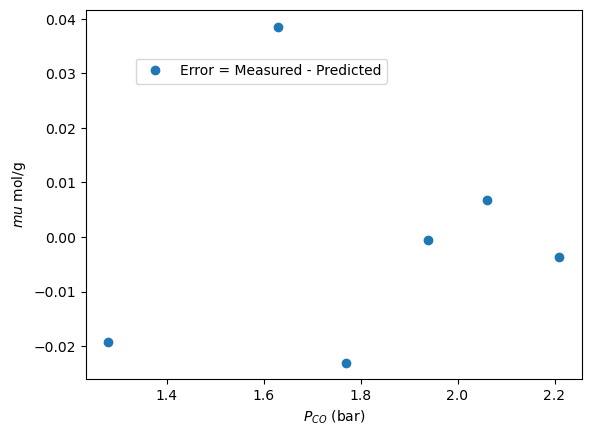

The model is probably OK within the pressure range of the measurements.


In [6]:
perr = np.sqrt(np.diag(pcov))
residuals = CO_ads - Langmuir(P_CO,*popt)
plt.plot(CO_ads, residuals,'o', label = 'Error = Measured - Predicted')
plt.legend(fontsize=10,loc=(0.1,0.8))
plt.xlabel(r'$P_{CO}$ (bar)')
plt.ylabel(r'$mu$ mol/g')
plt.show()
print ('The model is probably OK within the pressure range of the measurements.')

# Q2. Too hot in here
Thermal ethane dehydrogenation, which you studied in the last homework, occurs at high $T$ and is plagued by the generation of “coke,” or a cake of primarily carbon. An alternative way to create ethylene is through oxidative dehydrogenation:

$\ce{ C2H6 (g) + O2 (g) -> C2H4(g) + H2O (g) }$

At 600 K over some catalyst the reaction is half-order in ethane, first-order in $\ce{O2}$, zero order in products, and has a pseudohomogeneous rate constant of 5.0 $\text{M}^{-1/2}\text{s}^{-1}$. (Note, I am completely making this up!) You plan to run the reaction in an isothermal, constant volume reactor starting with an 70:20:10 mixture of $\ce{N2}:\ce{C2H6}:\ce{O2}$ at 2 bar total pressure.

### Q2.1. Plot the rate of disappearance of $\ce{C2H6}$ and of $\ce{O2}$ vs $\ce{C2H6}$ conversion (don’t forget to balance the reaction and find the limiting reagent!).

Let's say 

$\ce{C2H6} = A \quad \ce{O2} = B \quad \ce{C2H4} = D \quad \ce{H2O} = E$

assume $N_{0} = 1 mol $

$N_{A0} = 0.2$ mol, $N_{B0} = 0.1$ mol 

$V = V_{0} = \frac{RT}{P}$ 

$r_{A} = kC_{A}^{0.5}C_{B} = k (\frac{N_{A0}}{V}(1-X))^{0.5} \frac{N_{A0}}{V}(\frac{N_{B0}}{N_{A0}} - 0.5X)$

$r_{B} = 0.5 r_{A}$

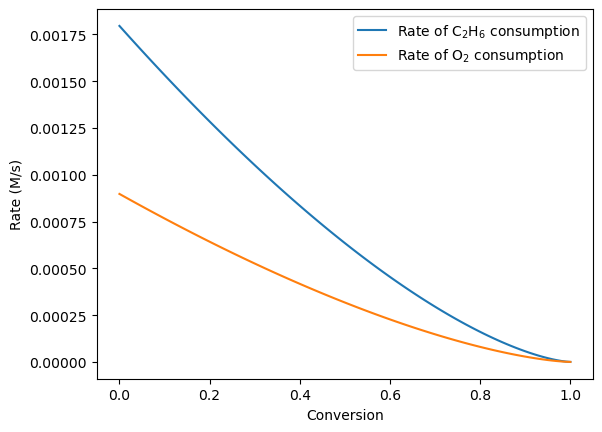

In [7]:
# Answer Here
k = 5.0 # M^(-1/2) s^(-1)
P = 2 # bar
R = 8.314 * 10**(-2)  # L bar K^(-1) mol^(-1)
T = 600 # K

V0 = R*T/P  # assume n0 = 1 mol

N_C2H6_0 = 1*0.2
N_O2_0 = 1*0.1

V = V0 # constant volume

rC2H6 = []
rO2 = []
x_list = np.linspace(0,1,100)

for x in x_list:
    C_C2H6 = N_C2H6_0/V * (1-x)
    C_O2 = N_C2H6_0/V * (N_O2_0/N_C2H6_0 - 0.5*x)

    rC2H6.append(k * C_C2H6**(0.5) * C_O2) # rate of C2H6 consumption
    
    rO2.append(k * C_C2H6**(0.5) * C_O2 * 0.5)  # rate of O2 consumption

plt.plot(x_list, rC2H6, label = 'Rate of C$_{2}$H$_{6}$ consumption')
plt.plot(x_list, rO2, label = 'Rate of O$_2$ consumption')
plt.xlabel('Conversion')
plt.ylabel('Rate (M/s)')
plt.legend()


### Q2.2. Plot the concentrations of all species vs residence time in the reactor.
Need to integrate the rate law vs time. Could do that numerically, using solve_ivp.

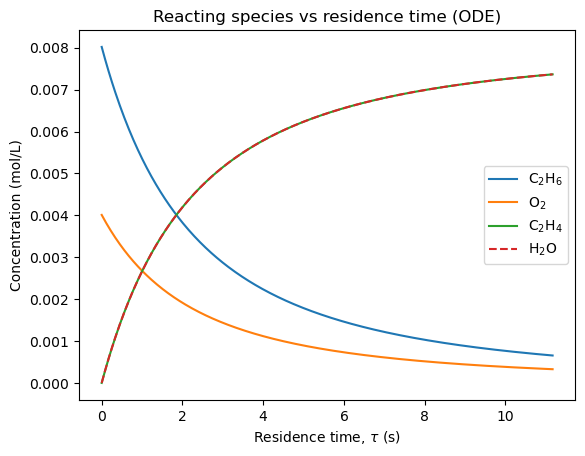

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ----- Problem data -----
k = 5.0           # (mol/L)^(-1/2) s^-1
T = 600.0         # K
P = 2.0           # bar
Rbar = 0.08314    # L·bar/(mol·K)

# Inlet totals: N0 = 1 mol -> V0 = RT/P, initial moles (N2:C2H6:O2 = 0.7:0.2:0.1)
N0 = 1.0
V0 = Rbar*T/P
nA0, nB0, nI0 = 0.20*N0, 0.10*N0, 0.70*N0          # A=C2H6, B=O2, I=N2
nD0, nE0 = 0.0, 0.0                                # D=C2H4, E=H2O

# Convert to concentrations (mol/L)
C_A0, C_B0, C_I0 = nA0/V0, nB0/V0, nI0/V0
C_D0, C_E0 = nD0/V0, nE0/V0

# State y = [C_I, C_A, C_B, C_D, C_E]
def rhs(tau, y):
    C_I, C_A, C_B, C_D, C_E = y
    r = k * (max(C_A, 0.0)**0.5) * max(C_B, 0.0)   # mol/(L·s)
    return [0.0, -2*r, -r, +2*r, +2*r]                   # N2 inert

# Event: stop when a reactant is depleted
def stop_when_out(tau, y):
    return min(y[1], y[2])                         # min(C_A, C_B)
stop_when_out.terminal = True
stop_when_out.direction = -1

y0 = [C_I0, C_A0, C_B0, C_D0, C_E0]

# A reasonable upper τ from initial rate
r0 = k * (C_A0**0.5) * C_B0
tau_guess = 5 * C_B0 / max(r0, 1e-12)

sol = solve_ivp(rhs, (0.0, tau_guess), y0, events=[stop_when_out],
                rtol=1e-9, atol=1e-12, dense_output=True)

# Sample solution on a grid
tau = np.linspace(0, sol.t[-1], 400)
C_I, C_A, C_B, C_D, C_E = sol.sol(tau)

plt.plot(tau, C_A, label=r"C$_2$H$_6$")
plt.plot(tau, C_B, label=r"O$_2$")
plt.plot(tau, C_D, label=r"C$_2$H$_4$")
plt.plot(tau, C_E, "--", label=r"H$_2$O")
plt.xlabel("Residence time, $\\tau$ (s)")
plt.ylabel("Concentration (mol/L)")
plt.title("Reacting species vs residence time (ODE)")
plt.legend()


Another way to solve this by integrating analytically

Let's say 

$\ce{C2H6} = A \quad \ce{O2} = B \quad \ce{C2H4} = D \quad \ce{H2O} = E$



$\frac{dN_{A}}{dt} = -r_{A}V$
 
$N_{A0}\frac{dX}{r_{A}V} = dt$

here,

$r_{A} = kC_{A}^{0.5}C_{B} = k (\frac{N_{A0}}{V}(1-X))^{0.5} \frac{N_{A0}}{V}(\frac{N_{B0}}{N_{A0}} - 0.5X)$

$dt = \frac{N_{A0}}{V} \frac{1}{kC_{A0}^2} \frac{dX}{r_{A}V}$

Integrate both sides

$t = \frac{1}{kC_{A0}} \int{\frac{1}{(1-X)^{0.5}(\gamma - 0.5X)}}dX, \quad \gamma = \frac{N_{B0}}{N_{A0}} = 0.5$


$t = \frac{1}{kC_{A0}} \frac{4}{(1-X)^{0.5}}$

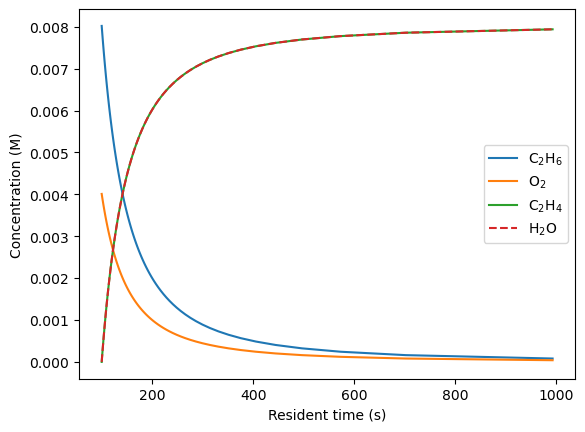

In [9]:
# Answer Here
N_C2H4_0 = 0
N_H2O_0 = 0

gamma = N_O2_0/N_C2H6_0

x_list = np.linspace(0.,1,100)
times = []

C_C2H6_list =[]
C_O2_list =[]
C_C2H4_list =[]
C_H2O_list =[]
C_N2_list =[]

for x in x_list[0:-1]:
    
    time = 1/k/(N_C2H6_0/V)* 4/((1-x)**(0.5))
    times.append(time)

    C_C2H6 = N_C2H6_0/V * (1-x)
    C_O2 = N_C2H6_0/V * (N_O2_0/N_C2H6_0 - 0.5*x)
    C_C2H4 = N_C2H6_0/V * (N_C2H4_0/N_C2H6_0 + x)
    C_H2O = N_C2H6_0/V * (N_H2O_0/N_C2H6_0 + x)
    C_N2 = 0.7
    
    C_C2H6_list.append(C_C2H6)
    C_O2_list.append(C_O2)
    C_C2H4_list.append(C_C2H4)
    C_H2O_list.append(C_H2O)
    C_N2_list.append(C_N2)

plt.plot(times, C_C2H6_list, label = 'C$_{2}$H$_6$')
plt.plot(times, C_O2_list, label = 'O$_2$')
plt.plot(times, C_C2H4_list, label = 'C$_2$H$_4$')
plt.plot(times, C_H2O_list, '--', label = 'H$_2$O')
plt.xlabel('Resident time (s)')
plt.ylabel('Concentration (M)')
plt.legend()

plt.show()

# Q3. Not a laughing matter
Nitrous oxide ($\ce{N2O}$) decomposes to $\ce{N2}$ and $\ce{O2}$ at high temperature. Experiments were performed at constant $T$ in a constant volume batch reactor. You can assume the reaction rate has the form $k P_{\ce{N2O}}^a$.

| $P_{\ce{N2O}}$$_{,0}$ (torr) | $T$ (K) | half-life (s) |
|-------------------------|---------|---------------|
|                    82.5 |    1030 |           860 |
|                     139 |    1030 |           470 |
|                     296 |    1030 |           255 |
|                     360 |    1030 |           212 |
|                     345 |    1085 |            53 |
|                     ~~360~~ |    ~~1030~~ |           ~~212~~ |
|                     294 |     967 |          1520 |

### Q3.1. What is the reaction order?
Consider data at 1030 K

In [10]:
P0 = np.array([82.5, 139, 296, 360])
half_t = np.array([860, 470, 255, 212])

### Half-life dependence on initial concentration
- **Zeroth-order**

  The rate law is  
  $-\frac{dP_A}{dt} = k$
  Integrated form gives:  
  $t_{1/2} = \frac{P_{A0}}{2k}$
  ⟶ Half-life would increase **linearly** with $P_{A0}$.

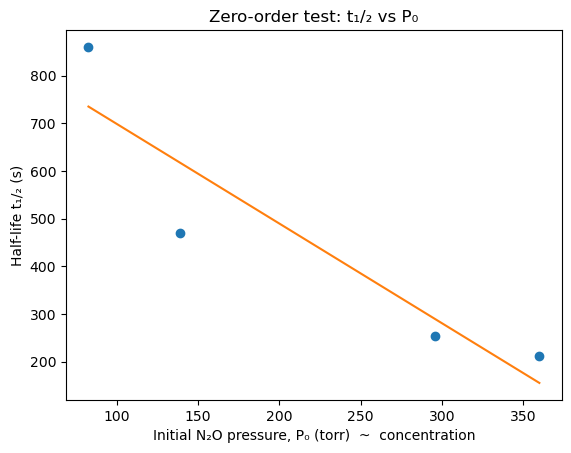

In [11]:
result = stats.linregress(P0, half_t)
model = result.intercept + result.slope*P0

plt.plot(P0,half_t,'o')
plt.plot(P0,model,'-')
plt.xlabel("Initial N₂O pressure, P₀ (torr)  ~  concentration")
plt.ylabel("Half-life t₁/₂ (s)")
plt.title(f"Zero-order test: t₁/₂ vs P₀")
plt.show()

Poor fit!

- **First-order reaction**  
  The rate law is  
  $-\frac{dP_A}{dt} = k P_A$
  Integrated form gives:  
  $t_{1/2} = \frac{\ln 2}{k}$
  ⟶ Half-life is **independent** of $C_{A0}$.

  Inspection of data shows that this is not correct.

---

- **Second-order reaction**  
  The rate law is  
  $-\frac{dP_A}{dt} = k P_A^2$
  Integrated form gives:  
  $t_{1/2} = \frac{1}{k P_{A0}}$
  ⟶ Half-life is **inversely proportional** to $P_{A0}$.

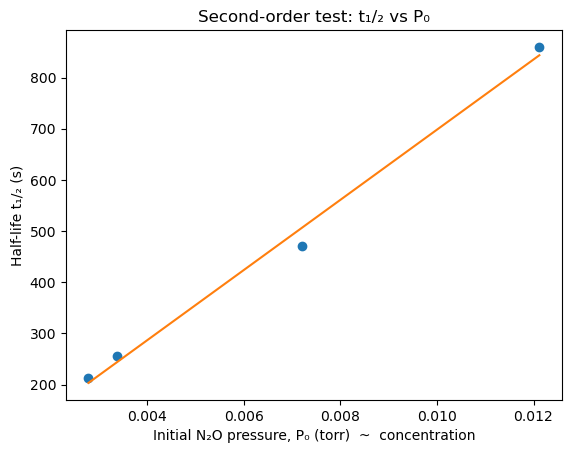

In [12]:
P0_inv = 1/P0
result = stats.linregress(P0_inv, half_t)
model = result.intercept + result.slope*P0_inv

plt.plot(P0_inv,half_t,'o')
plt.plot(P0_inv,model,'-')
plt.xlabel("Initial N₂O pressure, P₀ (torr)  ~  concentration")
plt.ylabel("Half-life t₁/₂ (s)")
plt.title(f"Second-order test: t₁/₂ vs P₀")
plt.show()

From this figure, we observe a linear relationship between the half-life and the inverse of pressure, indicating that the reaction follows second-order kinetics. The slope of the line corresponds to $\tfrac{1}{k}$.

### Another way to determine orders of reaction for fun
Equations of half-life for 1st and nth order are:


1st order: $t_{1/2} = \frac{[N_{2}O]_{0}}{2k}$

Is $t_{1/2}$ invariant to $P_{\ce{N2O},0}$?  NO! not 1st order

nth order: $t_{1/2} = \frac{2^{n-1}}{(n-1)k[N_{2}O]_{0}^{n-1}}$
‘
Here, $[N_{2}O] = \frac{P_{N_{2}O,0}}{RT}$


Assume 1st order

At the same T (= 1030 K), rate constant is the same.

$k = \frac{\ln\left(\frac{[N_{2}O]_{0}}{[N_{2}O]}\right)}{t}$

Take 1st and 2nd rows data, and calculate rate constant of each. 

$\rightarrow$ not the same. This is not 1st order reaction.


Let nth order,

Then k is

$k = \frac{2^{n-1}-1}{t_{1/2}(n-1)[N_{2}O]_{0}^{n-1}} = \frac{2^{n-1}-1}{(1/RT)^{n-1} t_{1/2}(n-1)P_{N_{2}O,0}^{n-1}}$

To simplify the equation, let's say 

$P_{N_{2}O,0} = P \quad  t_{1/2} = t$

at the same temperature, 

$\frac{k_{1}}{k_{2}} = 1 = \frac{t_{2} P_{2}^{n-1}}{t_{1} P_{1}^{n-1}}$

$n = 1+ \frac{ln(t_{1}/t_{2})}{ln(P_{2}/P_{1})}$

In [13]:
# Answer Here
half_t = [860, 470, 255, 212]
P0 = [82.5, 139, 296, 360]


n1 = 1+np.log(half_t[0]/half_t[1])/np.log(P0[1]/P0[0])
n2 = 1+np.log(half_t[0]/half_t[2])/np.log(P0[2]/P0[0])
n3 = 1+np.log(half_t[0]/half_t[3])/np.log(P0[3]/P0[0])
n4 = 1+np.log(half_t[1]/half_t[2])/np.log(P0[2]/P0[1])
n5 = 1+np.log(half_t[1]/half_t[3])/np.log(P0[3]/P0[1])
n6 = 1+np.log(half_t[2]/half_t[3])/np.log(P0[3]/P0[2])

print('n1 =', n1)
print('n2 =', n2)
print('n3 =', n3)
print('n4 =', n4)
print('n5 =', n5)
print('n6 =', n6)
print('average of n =',(n1+n2+n3+n4+n5+n6)/6)

n1 = 2.15819035519198
n2 = 1.951554321793365
n3 = 1.9504789660104103
n4 = 1.8089441223590441
n5 = 1.8366133242717426
n6 = 1.9434604687283246
average of n = 1.9415402597258111


n1 ~ n6 should be the same. But they are slightly different. This difference may come from an experimental error.

Thus, approximately reaction order, n $\approx$ 2 

### Q3.2. What is the apparent activation energy?

$k = \frac{2^{n-1}-1}{t_{1/2}(n-1)[N_{2}O]_{0}^{n-1}} = \frac{2^{n-1}-1}{(1/RT)^{n-1} t_{1/2}(n-1)P_{N_{2}O,0}^{n-1}}$

$n = 2$

$k = \frac{RT}{t_{1/2} P_{N_{2}O,0}}$

We can compute $k$ from each experiment and plot "ln k vs 1/T" (Arrhenius plot). The slope of Arrhenius plot is $-E_{a}/R$. 

Ea = 245.1 kJ/mol


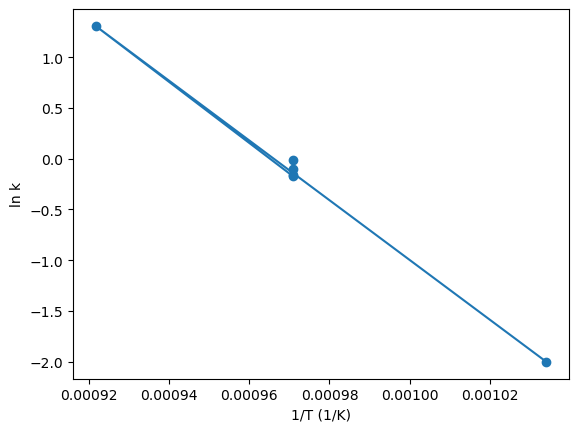

In [14]:
# Answer Here
import matplotlib.pyplot as plt

half_t_list = [860, 470, 255, 212, 53, 1520]
P0_list = [82.5, 139, 296, 360, 345, 294]
T_list = [1030, 1030, 1030, 1030, 1085, 967]
invT_list = [1/x for x in T_list] # 1/T list

lnk_list = []
R = 62.364 # L Torr K^(-1) mol^(-1)
for T,t,P0 in zip(T_list, half_t_list, P0_list):
    lnk_list.append(np.log(R*T/t/P0))

plt.plot(invT_list, lnk_list, 'o-')
plt.xlabel('1/T (1/K)')
plt.ylabel('ln k')

#obtain m (slope) and b(intercept) of linear regression line
m, b = np.polyfit(np.array(invT_list), np.array(lnk_list), 1)

LTorr_to_KJ = 0.133322368*10**(-3)

Ea = -m*R*LTorr_to_KJ

print('Ea = {:.1f} kJ/mol'.format(Ea))

# Q4. I’m getting dehydrated
*tert*-butanol can be dehydrated to isobutylene over an ion-exchange resin. An experiment was performed to follow the concentration of butanol vs time at 338 K. You can assume the reaction rate is only dependent on the concentration of *tert*-butanol under these reaction conditions.

| Time (h) | Butanol (M) |
|----------|-------------|
|        0 |        1.00 |
|     0.25 |        0.94 |
|     0.50 |        0.90 |
|     0.70 |        0.86 |
|     1.10 |        0.80 |
|     1.50 |        0.72 |
|     1.90 |        0.66 |
|     2.50 |        0.59 |
|     3.00 |        0.55 |
|     4.00 |        0.43 |
|     5.10 |        0.35 |
|     6.00 |        0.28 |

### Q4.1. "Write down the balanced reaction.

$\ce{C_4H_{9}OH -> C_4H_8 + H_2O}$ 

### Q4.2. What is the reaction order?

In [15]:
# Answer Here
time = np.array([0,0.25,0.50,0.70,1.10,1.50,1.90,2.50,3.00,4.00,5.10,6.00])*60*60 # convert unit of time from h to s
butanol = np.array([1.00,0.94,0.90,0.86,0.80,0.72,0.66,0.59,0.55,0.43,0.35,0.28]) # butanol concentration in M
# r = dc/dt
grad_t = np.gradient(time)  # second order approximation to gradient, allowing for unequal step size
grad_C = np.gradient(butanol)
rate = -np.divide(grad_C,grad_t)

**Assume reaction follows a power-law form. To get rate order, estimate rate vs time and either linearize and fit to get exponent or do a non-linear fit. Both approaches are shown here.**

The reaction order is 0.90.


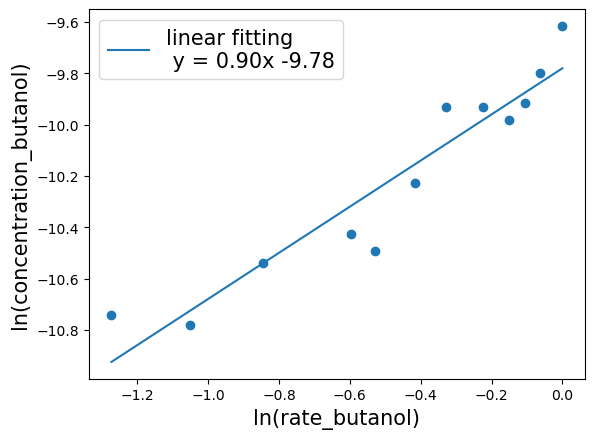

0.01392977075976469


In [16]:
# Approach 1: linear fitting to log(rate) vs log(concentration)
log_rate = np.log(rate)
log_conc = np.log(butanol)
a = np.polyfit(log_conc, log_rate, 1) # the slope of log_rate vs log_conc is reaction order alpha

print("The reaction order is {:.2f}.".format(a[0]))

# Visualize the log_rate vs log_conc and the linear fitting
fitted_log_rate = log_conc*a[0] + a[1]
plt.scatter(log_conc, log_rate)
plt.plot(log_conc, fitted_log_rate, label='linear fitting \n y = {:.2f}x {:.2f}'.format(a[0], a[1]))

plt.xlabel('ln(rate_butanol)',fontsize=15)
plt.ylabel('ln(concentration_butanol)',fontsize=15)
plt.legend(fontsize=15)

plt.show()

# Check the MSE of the fitting
difference_array = np. subtract(log_rate, fitted_log_rate)
squared_array = np. square(difference_array)
mse = squared_array. mean()
print(mse)

k = 0.000060, the reaction order alpha=1.04


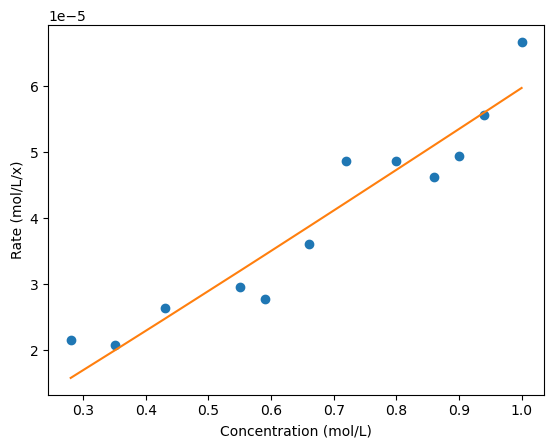

1.8496746800500784e-11


In [17]:
# Approach 2: use curve_fit and fit rate vs concentration directly

def differential(x, k, alpha):
    return k*x**alpha

popt, pcov = curve_fit(differential, butanol, rate)
print('k = {0:f}, the reaction order alpha={1:.2f}'.format(popt[0],popt[1]))

# Visualize the rate vs concentration and the fitting

plt.plot(butanol,rate,'o')
model = differential(butanol,popt[0],popt[1])
plt.plot(butanol,model,'-')
plt.xlabel('Concentration (mol/L)')
plt.ylabel('Rate (mol/L/x)')

plt.show()

# Check the MSE of the fitting
difference_array = np. subtract(rate, model)
squared_array = np. square(difference_array)
mse = squared_array. mean()
print(mse)

Both approaches suggest a rate order of 1. To double check, should fit original concentration vs time data to a first order model.

### Q4.3. What is the rate constant at this temperature?

# Approach 1 (preferred): fit concentration vs time data to first order model and extract k.

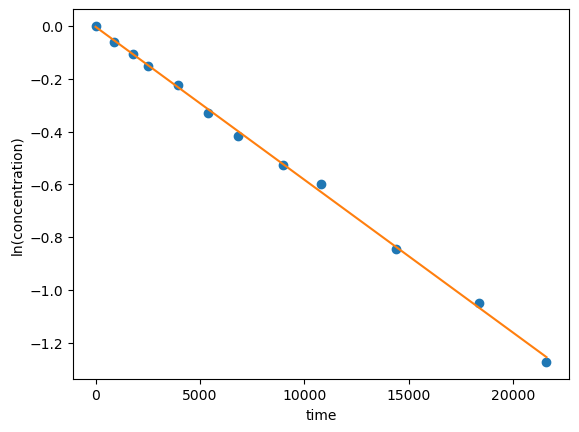

k=-5.794e-05 per M per s


In [32]:
result = stats.linregress(time, log_conc)
model = result.intercept + result.slope*time
plt.plot(time,log_conc,'o')
plt.plot(time,model,'-')
plt.xlabel("time")
plt.ylabel("ln(concentration)")
plt.show()
print("k={:.3e} per M per s".format(result.slope))

The rate constant at this temperature is 0.000062.


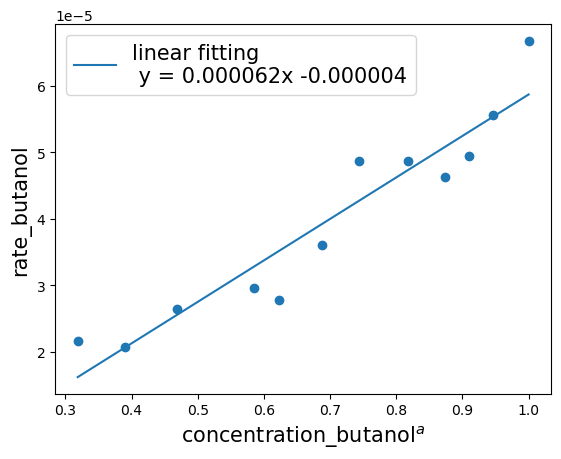

In [18]:

# Approach 2: linear fit to rate vs concetration to the power of reaction order
butanol_a = butanol**(a[0]) # concentration of butanol to the power of reaction order
b = np.polyfit(butanol_a, rate, 1) # the slope of rate vs butanol_a is the rate constant

print("The rate constant at this temperature is {:.6f}.".format(b[0]))

# Visualize the rate vs butanol_a and the linear fitting
fitted_rate = [i*b[0] + b[1] for i in butanol_a]
plt.scatter(butanol_a, rate)
plt.plot(butanol_a, fitted_rate, label='linear fitting \n y = {:.6f}x {:.6f}'.format(b[0], b[1]))

plt.xlabel('concentration_butanol$^a$',fontsize=15)
plt.ylabel('rate_butanol',fontsize=15)
plt.legend(fontsize=15)

plt.show()

k = 0.000058


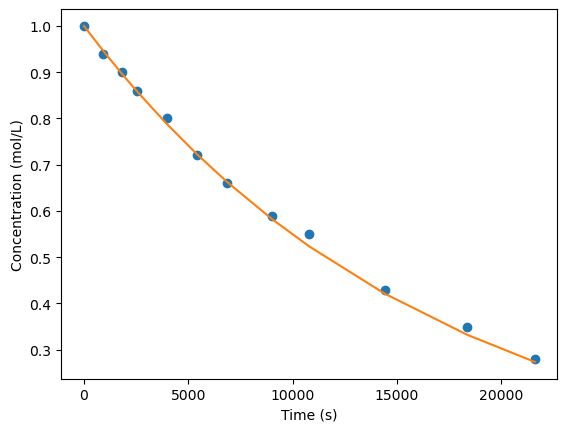

In [19]:
# If using approach #3 in question 3.2, then it suggests reaction order of 1

def integral(time, k): # integrated first-order rate law C = C0*exp(-kt)
    return np.exp(-k*time) # initial concetration is 1 M

popt1, pcov1 = curve_fit(integral, time, butanol, 0.000060) # initial gas of k is from question 3.2
print('k = {0:f}'.format(popt1[0]))

model1 = integral(time, popt1[0])
plt.plot(time,butanol,'o')
plt.plot(time,np.exp(-0.00006*time),'-')
plt.xlabel('Time (s)')
plt.ylabel('Concentration (mol/L)')
plt.show()

# Q5. Pressure packed
$\ce{NH3}$ synthesis from $\ce{N2}$ and $\ce{H2}$ was studied in a constant volume reactor (0.315 l) over a Ru catalyst, in a clever setup in which the $\ce{NH3}$ was continuously removed from the reactor.  The total pressure in the reactor was followed vs time at three different compositions and at 350 $^{\circ}\text{C}$. The pressures are reported as their equivalent values at 298 K (ie $N/V = P/R\times 298 \text{K}$).

$\ce{N2}:\ce{H2}:\ce{He}$ = 3:1:0

| Pressure (torr) | 766.2 | 731.9 | 711.9 | 686.2 | 661.5 |
|-----------------|-------|-------|-------|-------|-------|
| Time (min)      |     0 |    18 |    30 |    42 |    54 |

$\ce{N2}:\ce{H2}:\ce{He}$ = 1:1:2

| Pressure (torr) | 753.4 | 737.5 | 726.6 | 709.5 | 700.3 |
|-----------------|-------|-------|-------|-------|-------|
| Time (min)      |     0 |    15 |    30 |    45 |    54 |

$\ce{N2}:\ce{H2}:\ce{He}$ = 1:3:0

| Pressure (torr) | 707.1 | 700.2 | 693.2 | 683.5 | 675.5 |
|-----------------|-------|-------|-------|-------|-------|
| Time (min)      |     0 |    15 |    30 |    45 |    55 |

### Q5.1. Write down the balanced reaction.

$N_2+3H_2\rightarrow 2NH_3$

### Q5.2. Plot the $\ce{N2}$ and $\ce{H2}$ concentrations (mol/vol) vs time for each initial condition.

case 1:

| | $N_2$ | $H_2$ |  $NH_3$ | $He$ |
| --- | --- | --- | --- | --- |
| Initial | 3$n_0$ | $n_0$ | 0 | 0 |
| Change  | $-\epsilon$ | $-3\epsilon$ | $2\epsilon$| 0 |
| End | $3n_0-\epsilon$ | $n_0-3\epsilon$ |  $2\epsilon$ | 0 |

$N_{total} = 4n_0-4\epsilon$

$n_0 = \frac{P_0V}{4RT}$

$N_{total}= \frac{PV}{RT}$

$\epsilon = \frac{P_0V}{4RT}-\frac{PV}{4RT} = (P_0-P)\frac{V}{4RT}$

$c_{N_2} = \frac{(3n_0-\epsilon)}{V}$

$c_{H_2} = \frac{(n_0-3\epsilon)}{V}$

case 2:

| | $N_2$ | $H_2$ |  $NH_3$ | $He$ |
| --- | --- | --- | --- | --- |
| Initial | $n_0$ | $n_0$ | 0 | 2$n_0$ |
| Change  | $-\epsilon$ | $-3\epsilon$ | $2\epsilon$| 2$n_0$ |
| End | $n_0-\epsilon$ | $n_0-3\epsilon$ |  $2\epsilon$ | 2$n_0$ |

$N_{total} = 4n_0-4\epsilon$

$n_0 = \frac{P_0V}{4RT}$

$N_{total}= \frac{PV}{RT}$

$\epsilon = \frac{P_0V}{4RT}-\frac{PV}{4RT} = (P_0-P)\frac{V}{4RT}$

$c_{N_2} = \frac{(n_0-\epsilon)}{V}$

$c_{H_2} = \frac{(n_0-3\epsilon)}{V}$

case 3:

| | $N_2$ | $H_2$ |  $NH_3$ | $He$ |
| --- | --- | --- | --- | --- |
| Initial | $n_0$ | $n_0$ | 0 | 0 |
| Change  | $-\epsilon$ | $-3\epsilon$ | $2\epsilon$| 0 |
| End | $n_0-\epsilon$ | $3n_0-3\epsilon$ |  $2\epsilon$ | 0 |

$N_{total} = 4n_0-4\epsilon$

$n_0 = \frac{P_0V}{4RT}$

$N_{total}= \frac{PV}{RT}$

$\epsilon = \frac{P_0V}{4RT}-\frac{PV}{4RT} = (P_0-P)\frac{V}{4RT}$

$c_{N_2} = \frac{(n_0-\epsilon)}{V}$

$c_{H_2} = \frac{(3n_0-3\epsilon)}{V}$


In [20]:
P_1 = np.array([766.2,731.9,711.9,686.2,661.5])
t_1 = np.array([0,18,30,42,54])
P_2 = np.array([753.4,737.5,726.6,709.5,700.3])
t_2 = np.array([0,15,30,45,54])
P_3 = np.array([707.1,700.2,693.2,683.5,675.5])
t_3 = np.array([0,15,30,45,55])

T = 298 #K
V = 0.315e-3 #m3
R = 8.314 #m3*/Pa/K/mol
#convert pressure to Pa
P_1 = P_1*133.322
P_2 = P_2*133.322
P_3 = P_3*133.322

#calculate extant of reaction
e_1 = []
e_2 = []
e_3 = []
for i in range(len(P_1)):
 e_1.append((P_1[0]-P_1[i])*V/R/T/4) 
 e_2.append((P_2[0]-P_2[i])*V/R/T/4)
 e_3.append((P_3[0]-P_3[i])*V/R/T/4)

#calculate concentration
c_N2_1 = []
c_H2_1 = []
c_N2_2 = []
c_H2_2 = []
c_N2_3 = []
c_H2_3 = []
for i in range(len(e_1)):
  c_N2_1.append(3*P_1[0]/R/T/4-e_1[i]/V)
  c_H2_1.append(1*P_1[0]/R/T/4-3*e_1[i]/V)
  c_N2_2.append(1*P_2[0]/R/T/4-e_2[i]/V)
  c_H2_2.append(1*P_2[0]/R/T/4-3*e_2[i]/V)
  c_N2_3.append(1*P_3[0]/R/T/4-e_3[i]/V)
  c_H2_3.append(3*P_3[0]/R/T/4-3*e_3[i]/V)

#convert to mol/L

for i in range(len(c_N2_1)):
  c_N2_1[i] = c_N2_1[i]/10**3
  c_H2_1[i] = c_H2_1[i]/10**3
  c_N2_2[i] = c_N2_2[i]/10**3
  c_H2_2[i] = c_H2_2[i]/10**3
  c_N2_3[i] = c_N2_3[i]/10**3
  c_H2_3[i] = c_H2_3[i]/10**3

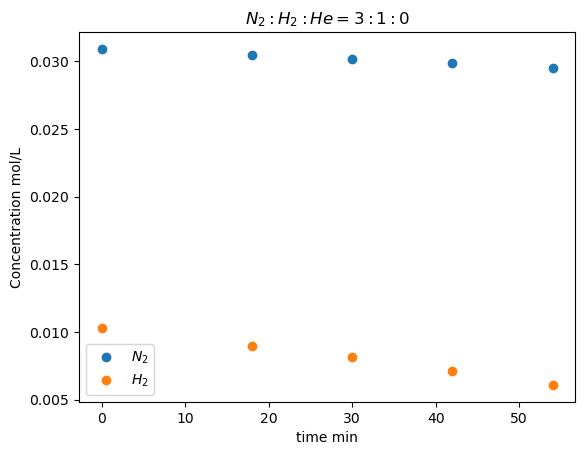

In [21]:
plt.plot(t_1,c_N2_1,'o',label = r'$N_2$')
plt.plot(t_1,c_H2_1,'o',label = r'$H_2$')
plt.ylabel('Concentration mol/L')
plt.xlabel('time min')
plt.title(r'$N_2:H_2:He=3:1:0$')
plt.legend()
plt.show()

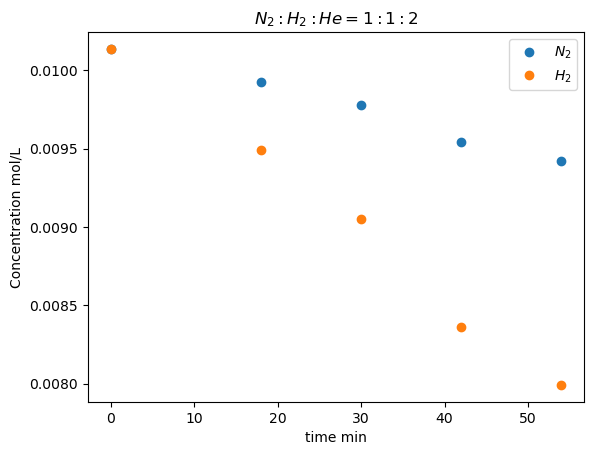

In [22]:
plt.plot(t_1,c_N2_2,'o',label = r'$N_2$')
plt.plot(t_1,c_H2_2,'o',label = r'$H_2$')
plt.ylabel('Concentration mol/L')
plt.xlabel('time min')
plt.title(r'$N_2:H_2:He=1:1:2$')
plt.legend()
plt.show()

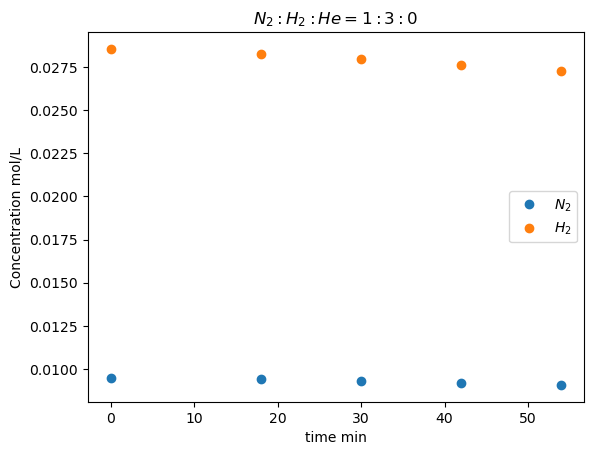

In [23]:
plt.plot(t_1,c_N2_3,'o',label = r'$N_2$')
plt.plot(t_1,c_H2_3,'o',label = r'$H_2$')
plt.ylabel('Concentration mol/L')
plt.xlabel('time min')
plt.title(r'$N_2:H_2:He=1:3:0$')
plt.legend()
plt.show()

### Q5.3. Use finite differences to make a table of reaction rates (moles/time/volume) vs composition (mol/vol $\ce{N2}$ and $\ce{H2}$).

$r = \frac{c(t_2)-c(t_1)}{t_2-t_1}$

In [24]:
def finite_diff_rates(time_min, cN2, cH2, label):
    rows = []
    for i in range(len(time_min)-1):
        dt = time_min[i+1] - time_min[i]   # min
        r = -(cN2[i+1] - cN2[i]) / dt      # mol/(L·min)
        rows.append({
            "Case": label,
            "Time (min)": 0.5*(time_min[i]+time_min[i+1]),
            "[N2] (mol/L)": 0.5*(cN2[i]+cN2[i+1]),
            "[H2] (mol/L)": 0.5*(cH2[i]+cH2[i+1]),
            "Rate (mol/(L·min))": r
        })
    return pd.DataFrame(rows)

df = pd.concat([
    finite_diff_rates(t_1, c_N2_1, c_H2_1, "N2:H2=3:1"),
    finite_diff_rates(t_2, c_N2_2, c_H2_2, "N2:H2=1:1:2"),
    finite_diff_rates(t_3, c_N2_3, c_H2_3, "N2:H2=1:3")
], ignore_index=True)
df

,Case,Time (min),[N2] (mol/L),[H2] (mol/L),Rate (mol/(L·min))
0,N2:H2=3:1,9.0,0.030692,0.009615,0.000026
1,N2:H2=3:1,24.0,0.030327,0.008520,0.000022
2,N2:H2=3:1,36.0,0.030019,0.007598,0.000029
3,N2:H2=3:1,48.0,0.029680,0.006580,0.000028
4,N2:H2=1:1:2,7.5,0.010028,0.009815,0.000014
5,N2:H2=1:1:2,22.5,0.009848,0.009274,0.000010
6,N2:H2=1:1:2,37.5,0.009660,0.008709,0.000015
7,N2:H2=1:1:2,49.5,0.009483,0.008178,0.000014
8,N2:H2=1:3,7.5,0.009466,0.028398,0.000006
9,N2:H2=1:3,22.5,0.009373,0.028118,0.000006


### Q5.4. Use your rate data to determine a rate law and rate constant for the reaction at these conditions.
Hypothesize that rate = k PN2^alpha PH2^beta. Could use non-linear regression to fit all the data (best choice in python). Alternatively, linearize the model and use linear regression, as done here.

In [25]:
# ---------------- Fit rate law: ln r = ln k + n ln[N2] + m ln[H2] ----------------
mask = (df["Rate (mol/(L·min))"] > 0) & (df["[N2] (mol/L)"] > 0) & (df["[H2] (mol/L)"] > 0)
lnr = np.log(df.loc[mask, "Rate (mol/(L·min))"].values)
lnN2 = np.log(df.loc[mask, "[N2] (mol/L)"].values)
lnH2 = np.log(df.loc[mask, "[H2] (mol/L)"].values)

# Linear regression with intercept
X = np.column_stack([np.ones_like(lnr), lnN2, lnH2])  # [1, ln[N2], ln[H2]]
beta, *_ = np.linalg.lstsq(X, lnr, rcond=None)
lnk, n, m = beta
k = np.exp(lnk)

# R^2
yhat = X @ beta
SS_res = np.sum((lnr - yhat)**2)
SS_tot = np.sum((lnr - lnr.mean())**2)
R2 = 1.0 - SS_res/SS_tot

print(f"\nFitted rate law: r = k [N2]^n [H2]^m")
print(f"n (order in N2) = {n:.3f}")
print(f"m (order in H2) = {m:.3f}")
print(f"k = {k:.3e} (units: mol^(1-n-m) · L^(n+m-1) · min^-1)")
print(f"R^2 (log-space fit) = {R2:.4f}")


Fitted rate law: r = k [N2]^n [H2]^m
n (order in N2) = 0.554
m (order in H2) = -0.447
k = 2.081e-05 (units: mol^(1-n-m) · L^(n+m-1) · min^-1)
R^2 (log-space fit) = 0.8915


Results suggest N2 order is +1/2, H2 order is -1/2. Could double check by integrating this rate law and testing it against concentration vs time data.